<a href="https://colab.research.google.com/github/Ritikkumar09/ML-projects/blob/main/Regression_Model__Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

import tensorflow_decision_forests as tfdf


In [2]:
df = pd.read_csv("/content/train.csv")

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df = df.drop("Id", axis=1)

In [5]:
df.head()


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


in linear model need to encoding of object data

For simplicity and faster experimentation, pd.get_dummies() was used. In production environments, OneHotEncoder is preferred for pipeline integration and handling unseen categories.

In [6]:
#one hot encoding
df_encoded = pd.get_dummies(df)

OneHotEncoding is done using get_dummies() methods

In [7]:
df_encoded

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,True,False,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,True,False,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,True,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,False,False,False,True,False,False,False,False,True,False
1456,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,False,False,False,True,False,False,False,False,True,False
1457,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,False,False,False,True,False,False,False,False,True,False
1458,20,68.0,9717,5,6,1950,1996,0.0,49,1029,...,False,False,False,True,False,False,False,False,True,False


split X and Y

In [8]:
X = df_encoded.drop("SalePrice", axis=1)
y = df_encoded["SalePrice"]

In [9]:
X

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,True,False,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,True,False,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,True,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,False,False,False,True,False,False,False,False,True,False
1456,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,False,False,False,True,False,False,False,False,True,False
1457,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,False,False,False,True,False,False,False,False,True,False
1458,20,68.0,9717,5,6,1950,1996,0.0,49,1029,...,False,False,False,True,False,False,False,False,True,False


In [10]:
y

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000
...,...
1455,175000
1456,210000
1457,266500
1458,142125


In [11]:
X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.2, random_state=42 )

linear regression

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

ValueError: Input X contains NaN.
LinearRegression does not accept missing values
so, 1st we need to fill missing value in column then encoding the column.
Lets start again from starting Steps follow in this format:
1️⃣ Load data
2️⃣ Separate target (SalePrice)
3️⃣ Identify numeric & categorical columns
4️⃣ Handle missing values
5️⃣ Encode categorical columns
6️⃣ Split train into train/validation
7️⃣ Train model
8️⃣ Evaluate (RMSE)
9️⃣ Predict test.csv


In [1]:
import pandas as pd
import numpy as np
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

In [2]:
test_id = test_df["Id"]

train_df = train_df.drop("Id", axis=1)
test_df = test_df.drop("Id", axis=1)


In [3]:
y = train_df["SalePrice"]
X = train_df.drop("SalePrice", axis=1)

Identify the column and seperate object type and numerical type

In [4]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1460 entries, 0 to 1459
Series name: SalePrice
Non-Null Count  Dtype
--------------  -----
1460 non-null   int64
dtypes: int64(1)
memory usage: 11.5 KB


In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [6]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

Handle NAN(missing values from column including numerical column and categorical column, so fill in numerical column with median value of the column and fill the in categorical column with most frequent value.


In [7]:
from sklearn.impute import SimpleImputer

SimpleImputer is an essential first step in data cleaning because many machine learning algorithms cannot process datasets with missing values

In [8]:
num_imputer = SimpleImputer(strategy="median")
X[num_cols] = num_imputer.fit_transform(X[num_cols])
test_df[num_cols] = num_imputer.transform(test_df[num_cols])

In [9]:
cat_imputer = SimpleImputer(strategy="most_frequent")
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])
test_df[cat_cols] = cat_imputer.transform(test_df[cat_cols])

In [10]:
#Combine train + test to avoid column mismatch
full_df = pd.concat([X, test_df], axis=0)


In [11]:
#one-hot-encoding
full_encoded = pd.get_dummies(full_df)

In [12]:
#split back train and test data
X_encoded = full_encoded.iloc[:len(X)]
X_test_encoded = full_encoded.iloc[len(X):]

In [13]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 0 to 1459
Columns: 287 entries, MSSubClass to SaleCondition_Partial
dtypes: bool(251), float64(36)
memory usage: 779.9 KB


In [14]:
#split data into train and validation
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [17]:
X_train.shape

(1168, 287)

In [18]:
y_train.shape

(1168,)

In [19]:
#validate the model
val_pred = lr.predict(X_val)

In [20]:
from sklearn.metrics import mean_squared_error
lr_rmse = np.sqrt(mean_squared_error(val_pred, y_val))

In [21]:
print(f"Validation accuracy is {lr_rmse}")

Validation accuracy is 29557.709302425308


In [22]:
test_pred = lr.predict(X_test_encoded)

In [23]:
print(test_pred)

[118501.77322395 160199.10110869 185840.72569234 ... 180294.49860081
 109471.96117413 222961.11438531]


We’ll use classical ML regression models (industry standard):

Linear Regression (baseline)

Ridge Regression

Lasso Regression

Random Forest Regressor

In [24]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

In [25]:
def evaluate_model(model, X_train, X_val, y_train, y_val):
  model.fit(X_train, y_train)
  preds = model.predict(X_val)
  rmse = np.sqrt(mean_squared_error(preds, y_val))
  return rmse

In [31]:
lr = LinearRegression()
lr_rmse = evaluate_model(lr, X_train, X_val, y_train, y_val)
print("Linear regression RMSE:", lr_rmse)

Linear regression RMSE: 29557.709302425308


In [33]:
ridge = Ridge()
ridge_rmse = evaluate_model(ridge,X_train, X_val, y_train, y_val)
print("Ridge regression RMSE:", ridge_rmse)

Ridge regression RMSE: 29650.577090194296


In [34]:
lasso = Lasso()
lasso_rmse = evaluate_model(lasso, X_train, X_val, y_train, y_val)
print("Lasso regression RMSE:",lasso_rmse)

Lasso regression RMSE: 28180.636603971496


In [35]:
random_forest = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_rmse = evaluate_model(random_forest, X_train, X_val, y_train, y_val)
print("Randome forest resgression RMSE:", rf_rmse)

Randome forest resgression RMSE: 28671.16112385057


In [36]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest"],
    "RMSE": [lr_rmse, ridge_rmse, lasso_rmse, rf_rmse]
})

results.sort_values(by="RMSE")


,Model,RMSE
2,Lasso Regression,28180.636604
3,Random Forest,28671.161124
0,Linear Regression,29557.709302
1,Ridge Regression,29650.577090


In this project, four regression models—Linear Regression, Ridge Regression, Lasso Regression, and Random Forest—were evaluated on the House Prices dataset. The evaluation metric used was Root Mean Squared Error (RMSE). Among all models, Lasso Regression achieved the lowest RMSE of 28,180, demonstrating superior performance due to effective feature selection.

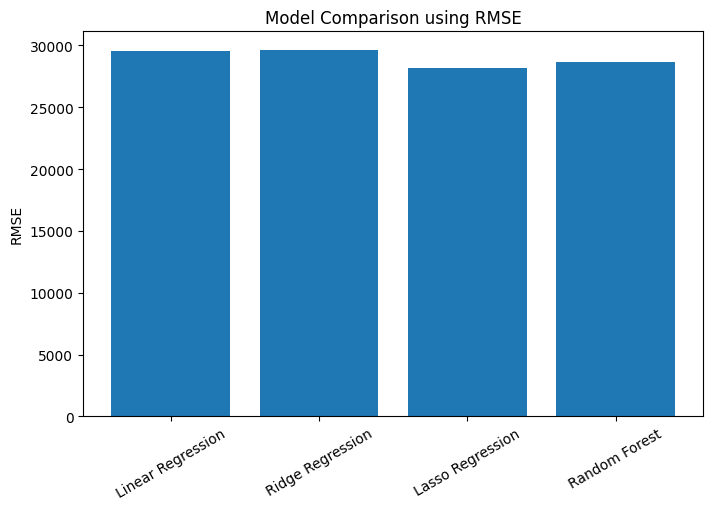

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["RMSE"])
plt.ylabel("RMSE")
plt.title("Model Comparison using RMSE")
plt.xticks(rotation=30)
plt.show()
